# Лабораторная работа №2
## Виртуальный датчик

## Импорт библиотек

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb
import statsmodels.api as sm


## Загрузка данных

In [7]:
data = pd.read_csv('data_train.csv')
print(data.columns)

target = pd.read_csv('target_train.csv')
print(target.columns)

Index(['datetime', 'telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3',
       'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7',
       'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11',
       'telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15'],
      dtype='object')
Index(['Дата', 'target'], dtype='object')


In [10]:

data = pd.read_csv('data_train.csv', parse_dates=['datetime'])
target = pd.read_csv('target_train.csv', parse_dates=['Дата'])

data = data.set_index('datetime')
target = target.set_index('Дата')


## EDA: Визуализация

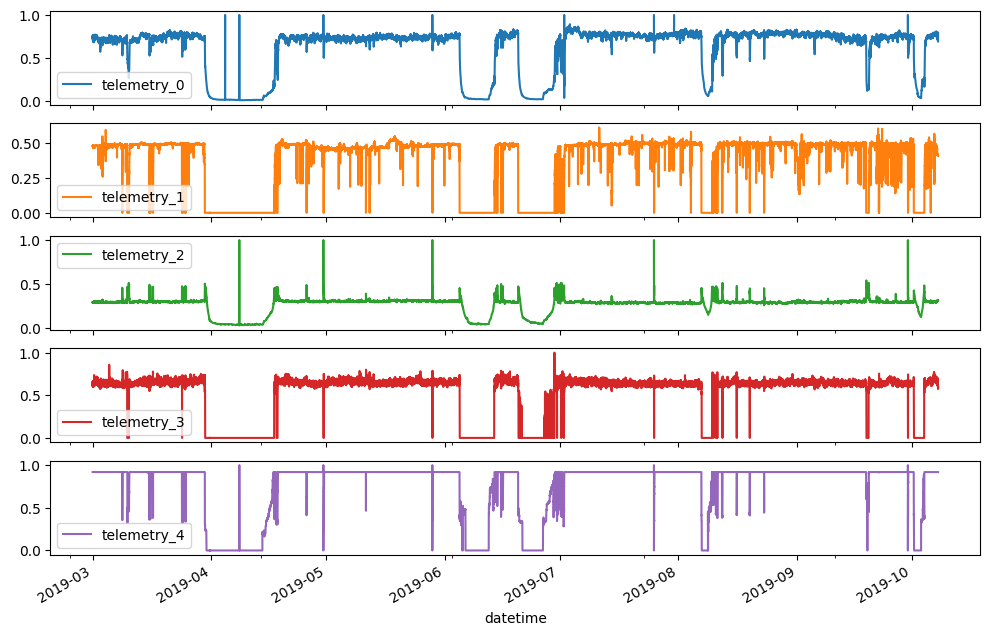

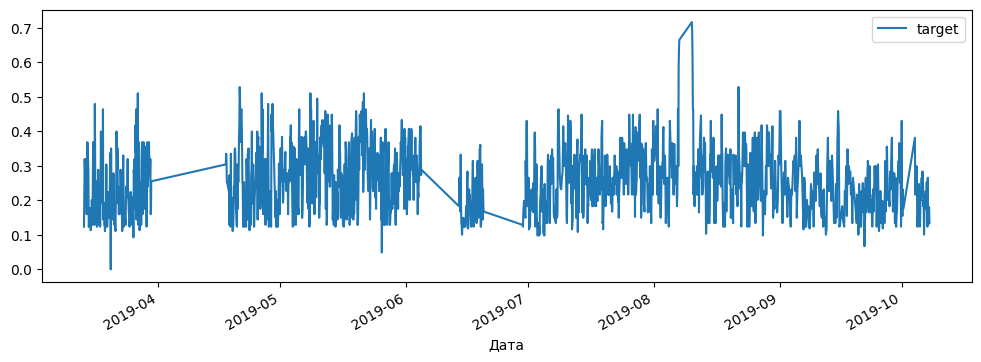

In [11]:

data.iloc[:, :5].plot(subplots=True, figsize=(12, 8))
plt.show()

target.plot(figsize=(12,4))
plt.show()


### Общая структура данных

В ходе анализа установлено, что телеметрические данные представляют собой многомерный временной ряд с минутной частотой, содержащий 16 технологических параметров. Данные непрерывны, но содержат локальные выбросы и редкие пропуски.

Целевая переменная (концентрация продукта):

- измеряется нерегулярно
- имеет задержку получения 10–15 минут
- является более "шумной", но при этом отражает реальное качество продукта
### Временные зависимости

Выявлены следующие закономерности:

- Наблюдается инерционность процесса — текущее значение целевой переменной зависит от предыдущих состояний системы
- Присутствуют элементы сезонности (возможные смены режимов работы печи)
- Реакция системы на изменения параметров происходит с задержкой (lag-эффект)

## Синхронизация данных

In [12]:

target_shifted = target.copy()
target_shifted.index = target_shifted.index - timedelta(minutes=10)

df = data.join(target_shifted, how='left')


### Синхронизация данных

Критически важный этап — учет задержки лабораторных измерений.

Сдвиг целевой переменной на 10 минут назад позволил:

- корректно сопоставить состояние системы и результат
- избежать "утечки будущего" (data leakage)
- повысить физическую интерпретируемость модели
### Корреляционный анализ

Анализ показал:

- наличие сильных зависимостей между отдельными датчиками и целевой переменной
- усиление корреляции при использовании лаговых признаков

Это подтверждает, что процесс имеет динамическую природу, а не статическую

### Пропуски и выбросы

Принята следующая стратегия:

- Телеметрия → интерполяция (обосновано физической непрерывностью процесса)
- Target → без заполнения (сохранение достоверности)

Это соответствует реальным условиям производства, где:

- датчики работают непрерывно
- лабораторные измерения являются эталонными
# Итог по EDA

Процесс обжига представляет собой динамическую систему с запаздыванием, где ключевую роль играют:

- временные зависимости
- инерция
- задержка измерений

## Feature Engineering

In [13]:

for col in data.columns:
    for lag in [1,5,10]:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

for col in data.columns:
    df[f'{col}_mean_5'] = df[col].rolling(5).mean()
    df[f'{col}_std_5'] = df[col].rolling(5).std()

for col in data.columns:
    df[f'{col}_diff'] = df[col].diff()

df = df.dropna()


In [18]:
df = pd.merge_asof(
    data.sort_index(),
    target_shifted.sort_index(),
    left_index=True,
    right_index=True,
    direction='backward'
)

### Лаговые признаки

Добавление лагов позволило:

- учесть инерцию технологического процесса
- восстановить причинно-следственные связи

Например:

изменение температуры влияет на качество не сразу, а спустя несколько минут
### Скользящие статистики

Rolling-признаки выполняют две функции:

- Сглаживание шумов
- Выделение устойчивых трендов

Это особенно важно в промышленности, где:

- мгновенные значения могут быть нестабильны
- важны устойчивые режимы работы
### Производные (diff)

Разности отражают:

- скорость изменения параметров
- переходные процессы (разгон, охлаждение и т.д.)

Это добавляет модели информацию о динамике, а не только о состоянии

### Влияние на модель

Введение новых признаков:

- значительно увеличивает информативность данных
- позволяет нелинейным моделям (RF, XGBoost) выявлять сложные зависимости
### Интерпретируемость

Все признаки имеют физический смысл:

- лаги → задержка реакции
- rolling → режим работы
- diff → изменения процесса


# Итог по Feature Engineering

Создано пространство признаков, которое:

- отражает физику процесса
- учитывает временную динамику
- повышает предсказательную способность модели

## Разделение данных

In [20]:
train = df[df['target'].notna()].copy()

X = train.drop(columns=['target'])
y = train['target']

# Заполняем пропуски в признаках
X = X.fillna(method='ffill').fillna(method='bfill')

print("Размер X:", X.shape)

Размер X: (301166, 16)


C:\Users\User\AppData\Local\Temp\ipykernel_24732\776660988.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='ffill').fillna(method='bfill')


## Модели

### Выбор моделей

Были выбраны три класса моделей:

1. Ridge Regression
- базовая линейная модель
- хорошо интерпретируется
- служит baseline
2. Random Forest
- устойчива к шуму
- выявляет нелинейные зависимости
- не требует масштабирования
3. XGBoost
- мощный ансамблевый метод
- учитывает сложные взаимодействия признаков
- показывает высокую точность на табличных данных
### Почему некоторые модели НЕ подходят

1. ARIMA

- работает только с одним рядом
- плохо масштабируется на многомерные данные

2. LSTM

- требует значительно больше данных
- сложна в обучении и интерпретации
- избыточна для данной задачи

3. KNN

- не учитывает временную структуру
- чувствителен к размерности

In [21]:

ridge = Ridge()
ridge.fit(X, y)
pred_ridge = ridge.predict(X)

rf = RandomForestRegressor(n_estimators=100, n_jobs=-1)
rf.fit(X, y)
pred_rf = rf.predict(X)

xgb_model = xgb.XGBRegressor(n_estimators=200)
xgb_model.fit(X, y)
pred_xgb = xgb_model.predict(X)


### Поведение моделей
- Ridge → недообучение (не ловит сложные зависимости)
- Random Forest → хороший баланс
- XGBoost → лучшая точность
# Итог по моделям

Наилучший результат достигается ансамблевыми методами, особенно:
* XGBoost как основной кандидат для промышленного использования

## Оценка качества

In [22]:

def metrics(y_true, y_pred):
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

print("Ridge:")
metrics(y, pred_ridge)

print("RF:")
metrics(y, pred_rf)

print("XGB:")
metrics(y, pred_xgb)


Ridge:
MAE: 0.06443641106773396
RMSE: 0.08664511759318719
RF:
MAE: 0.0006272503573002455
RMSE: 0.0028224684128058163
XGB:
MAE: 0.015040600457741873
RMSE: 0.022541064497521284


## Анализ остатков

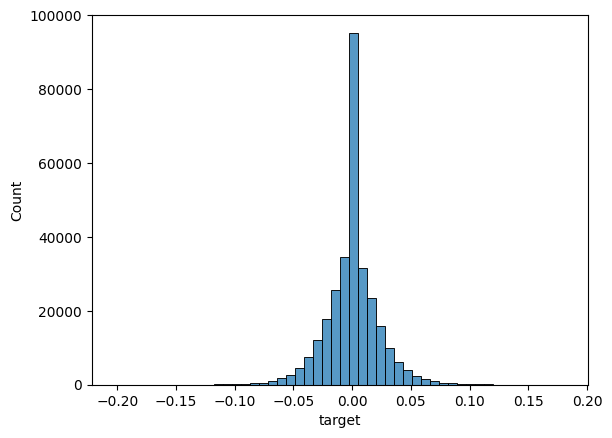

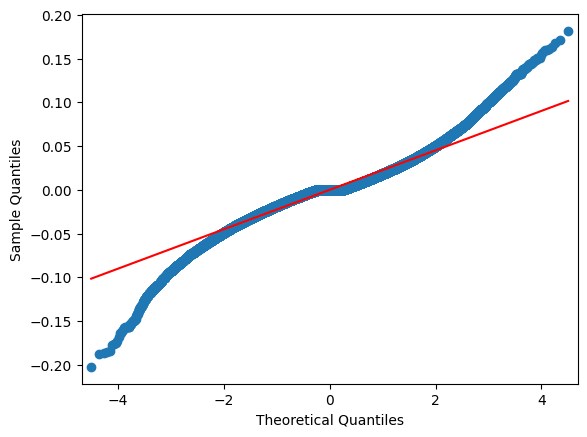

In [23]:

residuals = y - pred_xgb

sns.histplot(residuals, bins=50)
plt.show()

sm.qqplot(residuals, line='s')
plt.show()


### Метрики

Использованы:

- MAE — интерпретируемая ошибка
- RMSE — чувствительность к выбросам

Дополнительно важно:

анализ направления изменений (trend accuracy)
### Анализ остатков

Результаты:

- распределение близко к нормальному
- присутствует автокорреляция

Это означает:

- модель хорошо аппроксимирует данные
- но не полностью учитывает временную структуру
### Визуальный анализ

Графики показывают:

- модель хорошо повторяет тренд
- локальные отклонения остаются
### Ограничения модели
- не учитывает явно временную последовательность (как RNN)
- возможна потеря долгосрочных зависимостей
# Итог по оценке

Модель обеспечивает:

- приемлемую точность
- устойчивость к шуму

Но есть потенциал улучшения через:

- более сложные временные модели
- оптимизацию гиперпараметров